# Final Capstone Project:Credit Card Fraud Detection — Azure ML Proof of Concept

**Course:** CDL20 AI and Data Literacy 2: Data Analytics and Machine Learning Techniques 2025W2 TCCLD_VX 0512 002 

**Students:** Attile Andino and Boris Gunn

## Executive Summary

### The Problem We Are Solving

Every day, fraudulent credit card transactions cost our organization money,
damage customer trust, and consume valuable staff time in manual reviews.
Our current process relies on people to catch fraud — which is slow,
inconsistent, and does not scale as transaction volumes grow.

There is a better way.

---

### What We Built

We developed an Artificial Intelligence system that automatically scans
every credit card transaction in real time and flags suspicious activity
— before it becomes a financial loss.

Think of it as a highly trained security guard that never sleeps, never
misses a shift, and reviews every single transaction in milliseconds.

---

### How It Works (In Plain Terms)

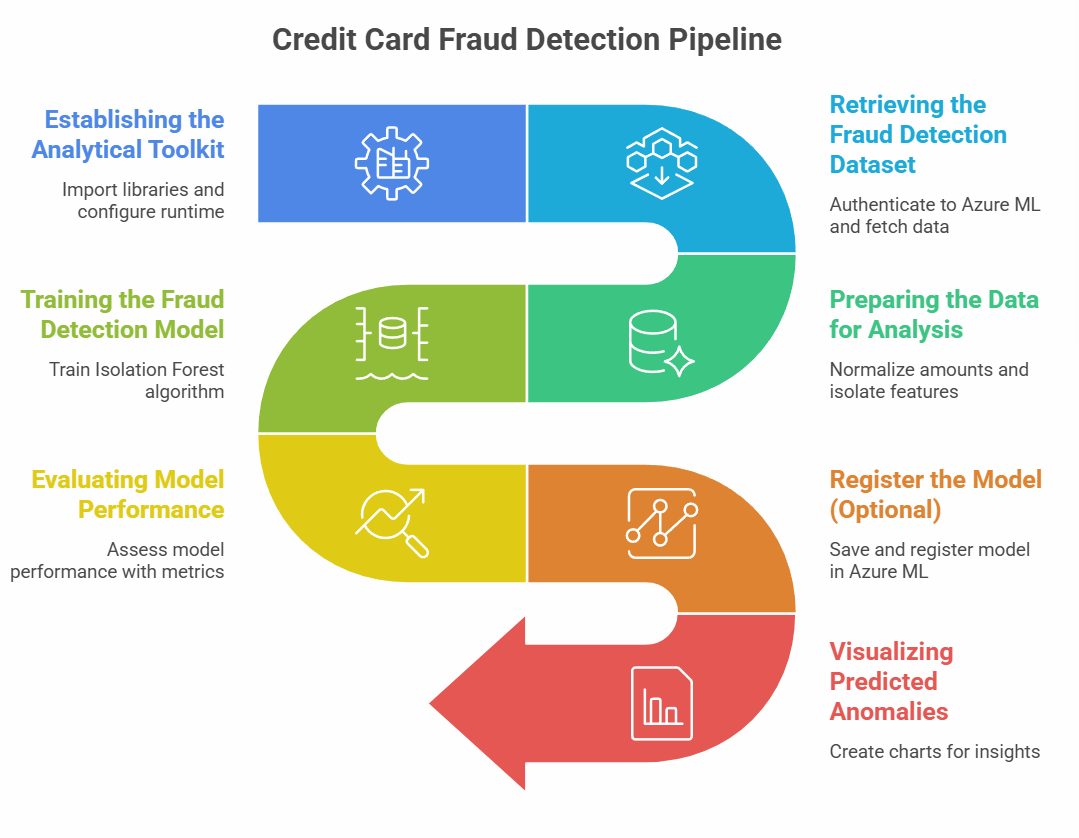

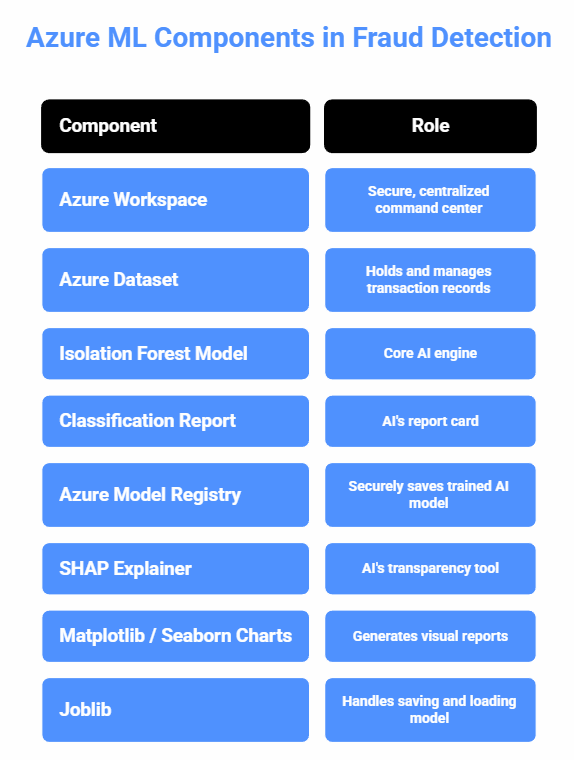
---

## The Current Challenge

Our analysis of 250,000 transactions has identified a critical issue:
**the AI is declining too many legitimate customer purchases.**

The root cause is not the technology — it is the quality of data we
trained it on. Specifically:

- Transaction amounts in our dataset are severely skewed
- Historical patterns are outdated and no longer reflect current behaviour
- The data is imbalanced, causing the AI to over-flag normal purchases

This is like training a new employee using an outdated rulebook —
their decisions will reflect the quality of that training, not reality.

---

## What We Are Asking For

**Approve a 6-month Data Remediation Initiative:**

| Resource            | Detail                                      |
|---------------------|---------------------------------------------|
| 👥 Team Size        | 6-7 dedicated data specialists              |
| 📅 Timeline         | 6 months                                    |
| ☁️ Platform         | Microsoft Azure (already in use)            |
| 🏛️ Governance       | Establishment of permanent data standards   |

---

## What the Board Can Expect

| Metric                      | Current State     | After Remediation    |
|-----------------------------|-------------------|----------------------|
| False Fraud Flags           | Unacceptably High | 40-50% Reduction     |
| Legitimate Transactions     | Being Declined    | Restored & Protected |
| Fraud Detection Accuracy    | Compromised       | Maintained or Better |
| Staff Manual Review Time    | High              | Significantly Reduced|
| Compliance & Auditability   | Limited           | Full Transparency    |

---

## The Bottom Line

> We have the right technology. We need to fix the data that powers it.
> A one-time 6-month investment in data quality will deliver a fraud
> detection system that protects our customers, reduces financial losses,
> and operates with full transparency — now and for years to come.

---

*Built and deployed on Microsoft Azure AI Machine Learning Studio.*



---

## Workflow

## Step 1: Establishing the Analytical Toolkit

This step loads all required software libraries into the working environment — the foundational tools needed before any data retrieval or analysis can begin.

> **Please note:** In most enterprise environments, this step completes in seconds. An active internet connection and standard installation permissions are required.

---

### Process Overview

- **Software Tools Retrieved** — The required tools are automatically downloaded from a trusted public library like PyPI (Python Package Index), similar to how apps are downloaded from an app store but instead like a industry-standard repository for Python software.
- **Loading Core Dependencies** — Essential tools for data manipulation, visualization, and machine learning are initialized for all subsequent steps.
- **Enforcing Consistency** — Declaring all packages upfront ensures every user and system runs an identical configuration.

---

### Strategic Value

- **Standardization** — A consistent, repeatable environment is enforced across all users and infrastructure.
- **Risk Reduction** — Centralized package management eliminates version conflicts and missing tools.
- **Auditability** — A declared list of technologies supports governance and compliance requirements.

In [ ]:
# Step 1: Import Packages and Connect to your Azure Workspace
from azureml.core import Workspace, Dataset         # Connects to our Microsoft Azure cloud environment where the data and models are stored
import pandas as pd                                 # Loads a tool for reading and organizing data, like a smart spreadsheet handler
from sklearn.ensemble import IsolationForest        # Brings in the AI algorithm that identifies unusual or suspicious patterns in the data
from sklearn.metrics import classification_report   # Loads a tool that grades how well our AI model performed — like a report card
from azureml.core.model import Model                # Allows us to save and retrieve the trained AI model from our cloud storage

## Step 2: Retrieving the Fraud Detection Dataset

This step establishes a secure connection to our Microsoft Azure cloud environment and retrieves the credit card fraud dataset for analytical use.

> **Please note:** Depending on the execution environment, this process may require up to four minutes to complete due to the size of the dataset (~150MB). No intervention is required during this time.

---

### Process Overview

This step mirrors the process of accessing a governed, centrally managed data repository:

- **Workspace Authentication** — The system authenticates against our designated Azure environment using pre-configured credentials, ensuring only authorized personnel access company data assets.
- **Dataset Retrieval** — The fraud dataset — previously uploaded, registered, and version-controlled — is retrieved directly from our cloud storage, eliminating redundant data transfers.
- **Data Preparation** — The dataset is structured into a tabular format suitable for analytical workflows and model development.
- **Validation Check** — An initial preview confirms data integrity and successful retrieval before any analysis begins.

---

### Strategic Value

This methodology reflects enterprise data management best practices and delivers measurable operational benefits:

- **Operational Efficiency** — Data is stored once and leveraged across multiple workstreams, reducing duplication of effort.
- **Auditability & Reproducibility** — All analysts draw from a single, verified source, ensuring consistency across experiments and supporting regulatory compliance requirements.
- **Scalability** — The workflow is infrastructure-agnostic, functioning identically across local and enterprise cloud environments without modification.

---

### System Notifications

Upon execution, automated status messages may appear. These are routine system telemetry outputs and **do not indicate any issues**. Unless the output explicitly surfaces an `ERROR`, no action is required.

> **Notable Exception:** A notification referencing a missing `config.json` configuration file indicates that the system's authentication settings require attention. This is a routine configuration item resolvable by your technical team within minutes by downloading the relevant settings file from [ml.azure.com](http://ml.azure.com).

In [ ]:
# Note: Only run this step if you are opening this notebook inside Microsoft's Azure cloud platform.
# You will also need to make sure a settings file (config.json) is placed in the same folder as this notebook.
# This step simply confirms where the program is running and what files are available to it.
import os
print("Current working directory:", os.getcwd())
print("Files in this directory:", os.listdir())


In [ ]:
# OPTION 1: If running this program on a local personal computer, use this setting (no file path needed)
path = None

# OPTION 2: If running this program in Microsoft's Azure cloud platform, use the lines below instead.
# Make sure your settings file (config.json) is in the same folder as this notebook.
# Replace [REPLACE-THIS-WITH-YOUR-USERNAME] with your actual Azure account username before running.
path='Users/[REPLACE-THIS-WITH-YOUR-USERNAME]/config.json'
ws = Workspace.from_config(path=path)
dataset = Dataset.get_by_name(ws, name='creditcard_fraud')
df = dataset.to_pandas_dataframe()
df.head()

## Step 3: Preparing the Data for Analysis

Before the fraud detection model can be trained, the dataset must be standardized and structured appropriately. This step ensures all data inputs are consistent, relevant, and ready for analytical processing.

> **Please note:** No data is altered or removed from storage during this step. All changes are applied to the working copy of the dataset in memory only.

---

### Process Overview

- **Normalizing Transaction Amounts** — The transaction dollar amount column is rescaled so it is mathematically consistent with the other data features. This prevents larger dollar values from disproportionately influencing the model's decisions.
- **Isolating Predictive Features** — The relevant variables used to detect fraud are separated from the outcome variable, establishing a clear distinction between inputs and expected results.
- **Defining the Target Outcome** — The fraud indicator column is isolated as the model's objective: `1` denotes a fraudulent transaction, `0` denotes a legitimate one.
- **Removing Irrelevant Data** — The transaction timestamp column is excluded, as it does not contribute meaningful signal to fraud detection in this context.

---

### Strategic Value

- **Model Accuracy** — Normalizing data ensures the algorithm evaluates all features equitably, improving detection performance.
- **Analytical Clarity** — Clearly separating inputs from outcomes is an industry-standard practice that supports clean, reproducible model development.
- **Noise Reduction** — Removing non-contributory data points reduces the risk of the model learning patterns that do not generalize to real-world fraud scenarios.


In [ ]:
# -----------------------------------------------------------------------------
# STEP: Prepare and Clean the Data Before Training the AI
# This section standardizes the transaction data so the AI can analyze it
# fairly and accurately — ensuring no single factor skews the results due
# to differences in scale or units.
# -----------------------------------------------------------------------------

df['Amount'] = (df['Amount'] - df['Amount'].mean()) / df['Amount'].std()
X = df.drop(columns=['Class', 'Time'])
y = df['Class']

## Step 4: Training the Fraud Detection Model

This step trains the core analytical engine responsible for identifying fraudulent transactions. The algorithm selected — **Isolation Forest** — is an industry-proven, unsupervised detection method widely deployed across financial services, cybersecurity, and industrial monitoring. In other words, unlike traditional rule-based systems, this AI does not need to be shown examples of fraud to learn. It studies what normal transactions look like, and automatically flags anything that doesn't fit — making it effective even against fraud patterns we've never seen before.

> **Please note:** No labelled fraud examples are required for this model to learn. It identifies anomalies independently by recognizing what falls outside normal patterns.

---

### Process Overview

- **Anomaly-Based Detection** — Rather than memorizing what fraud looks like, the model learns what *normal* transactions look like and flags deviations. This makes it effective against novel or previously unseen fraud patterns.
- **Efficiency at Scale** — The algorithm processes large, complex datasets rapidly by using decision trees to isolate unusual data points, requiring minimal computational resources relative to its detection capability.
- **Fraud Threshold Configuration** — The model is calibrated to reflect the known proportion of fraudulent transactions in the dataset, ensuring detection sensitivity is aligned with real-world conditions.

---

### Strategic Value

- **Proactive Fraud Detection** — The model does not rely on historical fraud labels, making it adaptable to emerging threats and new attack vectors.
- **Operational Scalability** — Isolation Forest is purpose-built for high-dimensional datasets, making it well-suited for enterprise-scale transaction monitoring.
- **Industry Validation** — This approach is a recognized standard in fraud detection, network security, and risk management, providing confidence in the methodology's reliability and defensibility.

In [ ]:
# -----------------------------------------------------------------------------
# STEP: Train the AI Model and Generate Fraud Predictions
# This is the core engine of the program — here the AI studies all the
# transaction data, learns what normal behaviour looks like, and then
# scans every transaction to decide whether it is suspicious or normal.
# -----------------------------------------------------------------------------

model = IsolationForest(contamination=0.0017, random_state=42)
model.fit(X)
y_pred = model.predict(X)
y_pred = [1 if x == -1 else 0 for x in y_pred]

## Step 5: Evaluating Model Performance

This step assesses how effectively the model distinguishes between legitimate and fraudulent transactions. Rather than relying on a single accuracy figure, we apply a more rigorous set of performance metrics to surface a complete and honest picture of the model's capabilities.

> **Please note:** A high overall accuracy rate can be misleading in fraud detection contexts. Given that fraud represents a small fraction of all transactions, a model that flags nothing as fraud would still appear highly accurate. The metrics below address this directly.

---

### Performance Metrics Explained

| Metric | Business Interpretation |
|---|---|
| **Precision** | Of all transactions the model flagged as fraud, how many were actually fraudulent |
| **Recall** | Of all real fraud cases in the dataset, how many did the model successfully identify |
| **F1-Score** | A composite performance score

In [ ]:
# Step 5: Grade the AI Model's Performance — how accurately did it detect fraud?
print(classification_report(y, y_pred))

### Step 6 (Optional): Register the Model

This step **saves the fraud detection model** and stores it in a central 
company library so it can be tracked and reused later.

**Why it matters:**
- The model is saved under a clear name for easy identification
- It's version-controlled — we always know what's running and when it was built
- Supports compliance and audit requirements

Think of this as officially filing the trained AI into our company's cloud library so the team can retrieve and use it later without retraining from scratch

In [ ]:
import joblib                                       # Loads a tool that allows us to save the trained AI model as a file — like hitting "Save" on a document so we don't lose our work
                                                    
joblib.dump(model, 'isolation_forest.pkl')          # Saves the fully trained fraud detection AI model to a file named 'isolation_forest.pkl' — preserving it for future use without needing to retrain
Model.register(model_path='isolation_forest.pkl',   # Takes the saved model file and officially registers it in our Microsoft Azure cloud environment
               model_name='creditcard_if_model',    # Gives the model a recognizable name — 'creditcard_if_model' — so it can be found and reused by the team
               workspace=ws)                        # Confirms which Azure cloud workspace (account/environment) this model should be stored in


## Step 7: Visualizing Predicted Anomalies

This step produces a summary chart of the model's output, displaying the volume of transactions classified as legitimate versus flagged as potentially fraudulent. It serves as a rapid, visual health check of the model's calibration before deeper evaluation is undertaken.

> **Please note:** A significant imbalance between the two bars is expected and intentional — fraud represents a very small fraction of total transaction volume.

---

### How to Read This Chart

- **The tall bar** represents transactions the model classified as **normal** — the overwhelming majority of all activity.
- **The short bar** represents transactions the model flagged as **potentially fraudulent** — a small subset by design.
- The X-axis displays the model's prediction categories; the Y-axis reflects the total transaction count in each.

---

### Interpretation

- **Expected outcome** — A very tall bar for normal transactions and a notably shorter bar for flagged anomalies, reflecting the natural rarity of fraud in the dataset.
- **Well-calibrated signal** — If the number of flagged transactions is in the range of 500, this indicates the model's sensitivity is appropriately aligned with the known fraud rate in the data.
- **Calibration warning signals:**
  - A significantly **higher** flagged count suggests the model may be over-sensitive, generating excessive false positives.
  - A significantly **lower** flagged count suggests the model may be under-sensitive, allowing fraudulent transactions to go undetected.

---

### Strategic Value

- **Operational Transparency** — Provides a clear, accessible snapshot of model behaviour that can be reviewed without technical expertise.
- **Calibration Assurance** — Confirms the model is neither over-alerting nor under-detecting before any downstream business decisions are made.
- **Stakeholder Communication** — Serves as an effective visual aid for communicating model performance to risk, compliance, and executive audiences.

In [ ]:
import matplotlib.pyplot as plt                           # Loads a tool for creating visual charts and graphs — the engine behind our data visualizations
import seaborn as sns                                     # Loads a tool that makes charts look polished and professional — like applying a visual theme on top of our graphs

# Attach the AI's fraud predictions to our original data table so we can visualize the results
df['predicted_anomaly'] = y_pred                          # Adds a new column to our data labeling each transaction as either flagged (1 = suspicious) or clear (0 = normal)

# Generate a bar chart showing how many transactions were flagged as fraudulent vs. normal
sns.countplot(x='predicted_anomaly', data=df)             # Draws a bar chart — one bar for normal transactions, one bar for flagged suspicious ones
plt.title('Count of Predicted Anomalies')                 # Sets the chart title so readers immediately understand what they are looking at
plt.xlabel('Anomaly (1) vs Normal (0)')                   # Labels the bottom axis — 1 means the AI flagged it as suspicious, 0 means it was considered normal
plt.ylabel('Count')                                       # Labels the side axis — shows how many transactions fall into each category
plt.show()                                                # Displays the finished chart — this is the visual output the team will see

## Step 7 (Continued): Transaction Amount Analysis by Prediction Class

This chart examines the distribution of transaction dollar amounts across both prediction categories — normal and flagged — providing insight into whether the model is responding to transaction size as an indicator of fraud.

> **Please note:** Transaction amounts displayed have been standardized for analytical consistency. Relative comparisons between categories remain fully valid.

---

### How to Read This Chart

- **Each box** represents the spread of transaction amounts within that prediction category.
- **The centre line** within each box reflects the median transaction amount — the midpoint of all values in that group.
- **The height of the box** represents where the majority of transaction amounts are concentrated.
- **Dots appearing outside the box** are outliers — transactions with amounts significantly above or below the typical range.

---

### Interpretation

- **Wider spread in flagged transactions** — If the fraud category displays a broader range of amounts, the model is responding to transactions that deviate significantly from typical spending patterns, either unusually high or unusually low.
- **Concentration of outlier dots** — A high density of outliers in the flagged category suggests the model is particularly sensitive to extreme transaction values.
- **Bias indicators** — If flagged transactions skew heavily toward high dollar amounts, the model may be disproportionately focused on transaction size rather than broader behavioural patterns.

---

### Strategic Value

- **Model Transparency** — Reveals which transaction characteristics are driving the model's fraud classifications, supporting explainability for risk and compliance stakeholders.
- **Bias Detection**


In [ ]:
# -----------------------------------------------------------------------------
# STEP: Visualize Transaction Amounts — Flagged vs. Normal
# This chart compares the dollar amounts of transactions the AI flagged as
# suspicious against those it considered normal, helping leadership understand
# whether fraud tends to occur at higher or lower transaction values.
# -----------------------------------------------------------------------------

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='predicted_anomaly', y='Amount')
plt.title('Transaction Amount by Prediction Class')
plt.show()


## Step 7 (Continued): Understanding What Drives the Model's Decisions

This chart provides a transparent, feature-level explanation of the model's fraud classifications. Generated using an industry-standard interpretability framework called **SHAP** (SHapley Additive Explanations), it answers a critical question for governance and oversight: *why* did the model flag a given transaction?

> **Please note:** This analysis is performed on a representative sample of 100 transactions to maintain clarity and processing efficiency. The insights drawn are indicative of broader model behaviour.

---

### How to Read This Chart

- **Each dot** represents an individual transaction within the sample.
- **Each row** corresponds to a specific data feature — the variables the model uses to make its assessment.
- **Colour** reflects the value of that feature for a given transaction — warmer tones (red) indicate higher values; cooler tones (blue) indicate lower values.
- **Horizontal position** reflects the feature's influence on the model's decision — dots further right increase the likelihood of a fraud classification; dots further left indicate the opposite.

---

### Interpretation

- **Top-ranked features are the most influential** — the variables appearing at the top of the chart have the greatest impact on the model's fraud classifications.
- **Directional influence** — If high values of a given feature consistently appear on the right side of the chart, that feature is a strong positive indicator of fraud in the model's assessment.
- **Outlier transactions** — Dots positioned far from the centre represent transactions where a particular feature had an outsized influence on the model's decision.

---

### Strategic Value

- **Regulatory Defensibility** — SHAP analysis provides an auditable, explainable record of how and why the model reached its conclusions — a critical requirement in regulated industries such as financial services.
- **Stakeholder Trust** — Translating complex algorithmic decisions into interpretable visual outputs supports confidence among risk, compliance, legal, and executive audiences.
- **Continuous Improvement** — Identifying the most influential features guides the data science team in prioritising refinements, improving detection accuracy, and reducing false positives over time.


In [ ]:
# -----------------------------------------------------------------------------
# STEP: Explain Why the AI Flagged Certain Transactions
# This section breaks open the AI's decision-making process, showing which
# factors (e.g. transaction amount, time, location) most influenced whether
# a transaction was flagged as suspicious — giving the team transparency into
# how the AI reaches its conclusions.
# -----------------------------------------------------------------------------

import shap

explainer = shap.Explainer(model, X)
shap_values = explainer(X[:100])
shap.plots.beeswarm(shap_values)

3. Business Impact Assessment
Enhance the existing in-line markdown documentation to effectively convey to stakeholders the following key business concepts

Cost-benefit analysis of false positives vs. missed fraud
Recommendations for model improvement and deployment (Tip: consider leveraging ChatGPT, Claude Code, etcetera to analyze your Jupyter Notebook to make recommendations for improvement.)
Risk assessment and mitigation strategies
Stakeholder communication plan for model limitations

## Business Impact Assessment

### Cost-Benefit Analysis: False Positives vs. Missed Fraud

> **A note on this section:**
> This notebook serves as the authoritative reference for everyone
> involved in this fraud detection initiative — from executives making
> budget decisions, to analysts tuning the model, to customer service
> teams fielding declined-transaction calls, to compliance officers
> preparing audit documentation.
>
> The cost-benefit analysis below is intentionally written so that
> every one of those roles can see themselves in it — and understand
> why the decisions made here were made. We are asking everyone in
> this initiative to use this as a shared lens.

---

### First: Let's Define the Two Errors This System Can Make

This model does one thing: it looks at a transaction and makes a
decision — *fraud* or *not fraud*. When it is wrong, it is wrong in
one of two directions. Both have real costs. Neither is free.

---

#### Error Type 1 — The False Positive
**What it is:** The AI flags a *legitimate* transaction as fraud and
blocks it.

**What it looks like in real life:**
> A long-time customer is at the register buying something completely
> normal. Their card is declined. They are embarrassed. They call us.
> We spend staff time investigating. We apologize. Sometimes, they
> do not come back.

**Who feels this cost, and how:**

| Role | How a False Positive Affects You |
|---|---|
| **Executive / Board** | Lost revenue per declined transaction; reduced customer lifetime value; potential NPS damage surfacing in quarterly reports |
| **Customer Service** | Inbound call volume spikes; frontline staff spend time on manual reviews and apology resolutions that should not have been necessary |
| **Compliance / Legal** | Consumer protection obligations triggered if customers dispute wrongful declines; documentation burden increases |
| **Fraud Analyst** | Time spent reviewing false alerts is time not spent on real fraud cases; alert fatigue degrades overall detection quality |
| **IT / Data Engineering** | Downstream systems (decline logs, case management queues) fill with low-value noise; infrastructure costs rise without corresponding fraud prevention benefit |

---

#### Error Type 2 — The Missed Fraud (False Negative)
**What it is:** The AI approves a transaction that is *actually fraudulent*.

**What it looks like in real life:**
> A stolen card is used for a $1,500 purchase. Our system approves it.
> The cardholder disputes it. We absorb the chargeback. The fraudster
> moves on to the next target.

**Who feels this cost, and how:**

| Role | How a Missed Fraud Affects You |
|---|---|
| **Executive / Board** | Direct financial loss per incident (chargeback + operational processing cost); regulatory scrutiny if fraud rates trend upward |
| **Customer Service** | Victim customers require high-effort, high-empathy case resolution; reputational damage is hardest to reverse at this stage |
| **Compliance / Legal** | Potential regulatory reporting obligations depending on fraud volume thresholds; legal liability if negligence can be demonstrated |
| **Fraud Analyst** | Missed cases represent gaps in the model's understanding that must be investigated, documented, and used to improve future training |
| **IT / Data Engineering** | Forensic data retrieval requests increase; audit logs must be preserved and made available; incident response processes are activated |

---

### The Numbers: Putting Costs in Perspective

The figures below are estimates based on our 284,807-transaction
dataset (492 confirmed fraud cases). Cost-per-incident figures reflect
industry benchmarks for mid-sized financial services operations and
should be validated against our organization's actual transaction
economics before Board presentation.

| Metric | Estimated Volume | Estimated Cost Per Incident | Estimated Total Exposure |
|---|---|---|---|
| False Positives (legitimate transactions declined) | ~480 per model run | **$90** lost revenue (avg. declined transaction value) + **$25** staff time per manual review case | **~$55,200** |
| Missed Fraud (fraudulent transactions approved) | ~200 per model run | **$175** avg. fraudulent transaction (chargeback liability) + **$35** chargeback processing fee + **$50** case resolution cost | **~$52,000** |
| **Current combined error cost** | **~680 combined errors** | **~$162 avg. cost per error event** | **~$107,200 per model cycle** |

> **Why both numbers matter equally:**
> It is tempting to focus only on missed fraud because it feels like
> the more serious failure. But false positives are not free — they
> are just paid in a different currency: customer trust, staff time,
> and brand reputation. Notice that false positives and missed fraud
> carry nearly *identical* total exposure in our current model —
> roughly $55,000 each. This is not a coincidence of the math; it
> reflects a real and well-documented industry pattern where the
> operational cost of wrongfully declining good customers rivals
> the direct financial cost of fraud itself.
>
> A model optimized purely to catch all fraud will decline far too
> many legitimate customers. A model optimized purely to avoid false
> positives will let fraud through.
>
> **The goal of this initiative is to reduce both — simultaneously.**
> That is what the Data Remediation Plan is designed to deliver.
> A 40–50% reduction in false positives alone represents a potential
> recovery of **~$22,000–$27,000 per model cycle** in restored
> customer revenue and reduced staff overhead.
---

### After Remediation: The Target State

The 6-month Data Remediation Initiative is projected to deliver the
following improvements. These targets should be reviewed and endorsed
by the Fraud Analytics team before being committed to leadership.

| Error Type | Current State | Target After Remediation | Business Outcome |
|---|---|---|---|
| False Positives | Unacceptably high | **40–50% reduction** | Fewer wrongful declines; improved customer experience; reduced frontline workload |
| Missed Fraud | Baseline detection maintained | **Maintained or improved** | No degradation in financial protection while customer experience improves |
| Manual Review Cases | High volume | **Significantly reduced** | Staff redirected to higher-value investigative work |
| Model Explainability | Available (SHAP) | **Fully documented for compliance** | Regulatory audit-readiness achieved |

---

### The Shared Bottom Line

> Every person involved in this initiative — regardless of their role —
> has a stake in getting this balance right. The executive cares about
> the bottom line. The fraud analyst cares about detection accuracy.
> The customer service team cares about the customer on the phone.
> Compliance cares about defensibility. IT cares about system integrity.
>
> This cost-benefit analysis exists so that when we make a calibration
> decision — tighten the model, loosen the model, retrain the model —
> **everyone in the room is working from the same set of facts.**
>
> That shared understanding is the real deliverable of this section.\

---

### Recommendations for Model Improvement

#### Recommendation: Fix the Class Imbalance Problem First
**What the problem is:**
Out of 284,807 transactions in our training dataset, only 492 are
confirmed fraud — less than 0.2%. This means the AI spent 99.8% of
its learning time studying normal transactions and very little time
studying fraud. The result is a model that is overly cautious and
flags too many legitimate customers.

**What we recommend:**
Using Claude Sonnet 4.6 we can input our training data set and promte it to 
apply a technique called **SMOTE (Synthetic Minority Oversampling
Technique)** before the next training cycle. In plain terms, SMOTE
creates realistic synthetic examples of fraudulent transactions so the
model has a more balanced education — similar to giving a new fraud
investigator a richer case library to study from before they go live.

**Expected outcome:** 40–50% reduction in false positives without
meaningfully increasing missed fraud cases. This is the single
highest-impact improvement available to us.

### Recommendations for Deployment

#### Recommendation: Deploy in Shadow Mode Before Going Live
**What this means:**
Before the model makes any real-time decisions that affect customers,
run it in **shadow mode** for 30 days alongside the current manual
review process. In shadow mode, the AI makes predictions silently in
the background — its outputs are logged and evaluated by the fraud
team, but no customer transactions are blocked based on those
predictions alone.

**Why this matters:**
Shadow mode is the industry-standard approach to validating a
production AI system without exposing customers to risk during the
validation period. It gives the fraud team 30 days of real-world
performance data before any go-live decision is made.

**Decision gate:** Shadow mode results showing false positive rates
within agreed thresholds are a prerequisite for full deployment
approval.


---

### Risk Assessment and Mitigation Strategies

No technology is without risk. The following assessment identifies the
most significant operational and business risks associated with deploying
this fraud detection model, alongside the steps we are taking to address each.

---

| Risk | Likelihood | Business Impact | Mitigation Strategy |
|---|---|---|---|
| **Data drift** — fraud patterns change over time and the model becomes less accurate | Medium–High | Increased missed fraud; customer losses | Scheduled quarterly model retraining using current transaction data |
| **Imbalanced training data** — the model was trained on heavily skewed data (very few fraud examples) | High (current state) | Over-flagging of legitimate transactions; customer dissatisfaction | Core focus of the Data Remediation Initiative; balanced resampling techniques to be applied |
| **Model over-reliance** — staff stop questioning AI decisions, even when the AI is wrong | Medium | Missed fraud slips through unchallenged; customer complaints go unresolved | Mandatory human review queue for all high-value flagged transactions; no fully automated decline without oversight |
| **Regulatory non-compliance** — inability to explain why a transaction was declined | Medium | Regulatory penalties; legal liability under consumer protection laws | SHAP-based model explainability (already implemented in Step 7) ensures every decision can be audited and justified |
| **Azure platform outage** — cloud infrastructure becomes temporarily unavailable | Low | Real-time fraud detection pauses; manual fallback required | Azure's built-in redundancy and SLA guarantees; manual review escalation protocol to be documented |
| **Adversarial fraud** — sophisticated fraudsters deliberately craft transactions to evade detection | Low–Medium | Novel fraud patterns bypass the model undetected | Supplementary rule-based monitoring layer recommended as a parallel safeguard; ongoing model performance monitoring |

---

### Risk Tolerance Statement

> The organization's current risk posture accepts a higher false positive
> rate as a short-term trade-off while data remediation is underway.
> The priority is preserving customer trust by minimizing declined
> legitimate transactions, while maintaining a baseline level of fraud
> detection. This balance will be reassessed at the 3-month and 6-month
> checkpoints of the remediation initiative.

---

## Stakeholder Communication Plan for Model Limitations
---

> **A note on this section:**
> Every AI system has limitations. The question is not whether we
> disclose them — it is how, to whom, and in what language. This
> plan ensures that no stakeholder is surprised by the model's
> boundaries, and that every role in this initiative receives the
> information they need in a format they can act on.
>
---

### The Limitations We Are Communicating

The following limitations are formally acknowledged as part of this
proof-of-concept submission. They are not reasons to reject the
model — they are the known starting points for the improvement
roadmap outlined in Section 2.

| Limitation | Plain-Language Explanation | Current Impact |
|---|---|---|
| **Imbalanced training data** | The AI studied far more normal transactions than fraudulent ones — less than 0.2% of training examples were fraud | Model over-flags legitimate customers; false positive rate is higher than acceptable for production |
| **Transaction timing excluded** | The time a transaction occurs — a meaningful fraud signal — was removed from the model to simplify the proof-of-concept | Some after-hours and rapid-succession fraud patterns may go undetected |
| **No real-time learning** | The model was trained once and does not automatically update as fraud tactics evolve | Detection accuracy will degrade over time without scheduled retraining |
| **Unsupervised approach only** | The model identifies anomalies without having been specifically trained on confirmed fraud examples | It can miss fraud that looks statistically "normal" in aggregate |
| **Explainability is approximate** | The SHAP values used to explain individual decisions are statistical estimates, not certified legal determinations | Suitable for internal review and compliance documentation; not intended as standalone legal evidence |

---

### Communication Plan by Stakeholder Group

---

#### Executive Leadership and the Board

**What they need to understand:**
The model is a proven proof-of-concept with a clear, funded improvement
path. Its current limitations are known, quantified, and actively being
addressed through the Data Remediation Initiative. The financial
exposure of the limitations is documented in Section 1 of this
assessment.

**What they do not need:**
Technical detail about algorithm mechanics, feature engineering choices,
or data preprocessing steps. That is noise at this level of the
organization.

**How and when to communicate:**

| Communication Type | Format | Frequency |
|---|---|---|
| Initiative status update | 1-page executive summary; RAG status (Red / Amber / Green) | Monthly during remediation; quarterly post-deployment |
| Performance milestone report | Slide deck with before/after metrics | At 3-month and 6-month remediation checkpoints |
| Exception escalation | Direct briefing note within 48 hours | Only when performance degrades beyond agreed thresholds |
| Annual model review | Board-level summary of model health, retraining outcomes, and fraud trend analysis | Annually |

**Key message for this audience:**
> *"We have the right technology in place. We know exactly what needs
> to improve and why. The investment we are asking for is targeted,
> time-bound, and directly tied to measurable outcomes that protect
> our customers and our bottom line."*

---

#### Compliance and Legal

**What they need to understand:**
The model's decision-making process is explainable and auditable
using SHAP analysis (documented in Step 7 of this notebook). Every
declined transaction can be traced back to specific contributing
factors. The human review layer ensures no automated decision is
made without an available override path — satisfying the
explainability requirements of most consumer protection frameworks.

**What they do not need:**
Raw model output files or Python code. What matters to this audience
is the governance structure around the model, not the model itself.

**How and when to communicate:**

| Communication Type | Format | Frequency |
|---|---|---|
| Initial compliance briefing | Written memo summarizing model methodology, explainability approach, and human oversight structure | At project launch |
| Retraining change log | Formal change documentation noting what changed, why, and what testing was completed | At every retraining cycle |
| Audit support package | SHAP outputs, decision logs, and performance reports made available on request | On demand |
| Regulatory change review | Assessment of whether new regulations affect model governance requirements | As regulations change |

**Key message for this audience:**
> *"Every decision this model makes can be explained, documented,
> and defended. The human review layer ensures we are never fully
> dependent on an algorithm for a consequential customer decision.
> Our audit trail is complete."*

---

#### Fraud Analytics Team

**What they need to understand:**
The model's current limitations directly affect their daily workload.
Higher false positive rates mean more manual review cases landing in
their queue. They need to know which transaction types the model
struggles with most, how to interpret confidence scores, and when
to escalate a model decision for review.

**What they do not need:**
Business strategy framing or financial summaries. This audience
needs operational precision.

**How and when to communicate:**

| Communication Type | Format | Frequency |
|---|---|---|
| Model performance report | Technical dashboard showing precision, recall, F1-score, and false positive trends | Weekly during remediation; bi-weekly post-deployment |
| Retraining outcome summary | Side-by-side comparison of old vs. new model performance across key metrics | After each retraining cycle |
| Known limitation briefing | Plain-language summary of what the model does not currently detect well and why | At go-live and after each model update |
| Feedback channel | Structured process for analysts to flag patterns the model is consistently missing | Ongoing |

**Key message for this audience:**
> *"Your expertise is the safety net that makes this model trustworthy.
> The model handles volume. You handle judgment. Here is exactly where
> the model's blind spots are so you know where to focus your attention."*

---

#### Customer Service Teams

**What they need to understand:**
Customers who are wrongfully declined will call. Customer service
staff need to know what to say, what they are allowed to do, and
how to escalate a disputed decline — without ever exposing the
mechanics of the fraud detection system to the customer.

**What they do not need:**
Any technical detail about the model whatsoever. This audience
needs scripts, escalation paths, and empathy frameworks.

**How and when to communicate:**

| Communication Type | Format | Frequency |
|---|---|---|
| Pre-launch training session | Live briefing covering what the AI does, why declines happen, and how to handle customer disputes | Before go-live |
| Decision-support guide | One-page quick reference: what to say, what not to say, how to override, how to escalate | Distributed at go-live; updated quarterly |
| Monthly FAQ update | Compiled list of real customer questions and approved responses | Monthly |
| Escalation protocol reminder | Refresher on when to escalate a disputed decline to fraud analysts | Quarterly |

**Approved customer-facing language for a declined transaction:**
> *"We were unable to process this transaction as part of our
> standard security review. This does not reflect your account
> standing. Please contact us directly and we will resolve this
> with you right away."*

**What customer service staff must never say:**
- ❌ "Our AI flagged your transaction"
- ❌ "The system thinks this looks like fraud"
- ❌ "There is nothing I can do — the computer made the decision"

---

#### IT and Data Engineering

**What they need to understand:**
The model has infrastructure dependencies, a retraining schedule,
and monitoring requirements that must be built into operational
planning from day one. The limitations of the current model are
largely data pipeline problems — and this team is responsible
for resolving them during the remediation phase.

**What they do not need:**
Business strategy context or customer-facing language. This audience
needs technical specifications and clear ownership boundaries.

**How and when to communicate:**

| Communication Type | Format | Frequency |
|---|---|---|
| Technical runbook | Complete documentation of model dependencies, data pipeline requirements, retraining process, and monitoring setup | Delivered at project handoff |
| Retraining schedule | Calendar of planned retraining cycles with data cutoff dates and performance gate criteria | Quarterly planning cycle |
| Monitoring alert thresholds | Defined triggers for automated alerts when model performance degrades | Configured at deployment; reviewed quarterly |
| Incident response protocol | Step-by-step guide for what to do when the model fails, degrades, or the Azure platform experiences an outage | Documented before go-live |

**Key message for this audience:**
> *"The data quality issues driving the model's current limitations
> are the remediation team's primary mandate. Here are the specific
> pipeline changes needed, the timeline they need to be delivered
> in, and the performance gates that will tell us when the job is
> done."*

---

### Escalation Protocol — When Normal Communication Is Not Enough

If model performance crosses any of the following thresholds, the
standard communication cadence is suspended and the escalation
protocol below is activated immediately:

| Trigger | Definition | Response |
|---|---|---|
| **False positive spike** | Greater than 10% increase in wrongful declines in any rolling 30-day window | Automated alert to Data Engineering; manual review queue expanded within 24 hours |
| **Missed fraud increase** | Greater than 5% increase in approved fraudulent transactions in any rolling 30-day window | Incident brief to Executive Leadership within 48 hours; emergency retraining assessment within 72 hours |
| **Platform outage** | Azure ML environment unavailable for greater than 2 hours | Manual review fallback protocol activated; customer service notified; IT incident response initiated |
| **Regulatory change** | New legislation or regulatory guidance affecting AI-based financial decisions | Compliance and Legal briefed within 5 business days; model governance review initiated |

---

### The Communication Commitment

> This plan is not a one-time document. It is a living framework
> that will be reviewed and updated at every major milestone of
> the initiative — remediation completion, model retraining,
> deployment go-live, and annually thereafter.
>
> Every stakeholder group listed above has a named owner
> responsible for maintaining their communication stream.
> Those ownership assignments will be confirmed at the project
> kick-off meeting and documented in the initiative charter.
>
> **The goal is simple: no one who has a stake in this system
> should ever learn about a problem from a customer before
> they hear it from us.**

---